In [25]:
# Annahmen
# Mehrfamilienhaus (Mfh) = 426 m^2 beheizte Wohnfläche (siehe Excel mit Quellen)
# Netto Trinkwarmwasserbedarf = 16,5 kWh/(m²*a)
# Anzahl Wohneinheiten = 6 --> 14,5 kW pro WE = 87 kW
# Installierbare PV-Leistung = 13 kWp (PV-Atlas)

# 3 Fälle je nach sanierungsgrad
# Fall 1: Ist-ZST (unsaniert)
# Netto Heizwärmebedarf  = 168,6	kWh/(m²*a)

# Fall 2: Konventionell (teilsaniert)
# Netto Heizwärmebedarf  = 82,5	kWh/(m²*a)

# Fall 3: zukunftsführend (vollständige Sanierung)
# Netto Heizwärmebedarf  = 25 kWh/(m²*a)





In [26]:
import pypsaheat as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
from pathlib import Path



In [27]:
# ------------------------------------------------------------
# 1) Allgemeine Einstellungen
# ------------------------------------------------------------

# Wir simulieren ein Jahr in Stundenauflösung
N_HOURS = 8760
snapshots = range(N_HOURS)

# HeatNetwork anlegen und Snapshots setzen
n = ph.HeatNetwork()
n.set_snapshots(snapshots)

In [28]:
# ------------------------------------------------------------
# Lasten laden
# ------------------------------------------------------------

# Fall auswählen (nur EINEN aktiv lassen)
lastgang_file = "../Input_Data/Archiv/2026-01-19-Mehrfamilienhaus-Lastprofile_Ist_ZST_Raumwaerme_cutoff15C.csv"
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_konventionell_Raumwaerme_cutoff15C.csv"
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_zukunftsfuehrend_Raumwaerme_cutoff15C.csv"

# Version automatisch aus Dateiname ableiten lassen
lf = lastgang_file.lower()
if "ist_zst" in lf:
    lastgang_version = "Ist_ZST"
elif "konventionell" in lf:
    lastgang_version = "konventionell"
elif "zukunft" in lf:
    lastgang_version = "zukunftsfuehrend"
else:
    lastgang_version = "unknown"

df = pd.read_csv(lastgang_file, sep=",", decimal=".")

# --- Zeitspalte finden ---
time_col = next((c for c in df.columns if "Zeit" in c), None)
if time_col is None:
    raise ValueError(f"Keine Zeitspalte gefunden. Spalten: {df.columns.tolist()}")

# --- Zeitspalte in datetime umwandeln ---
# falls bei dir sowas drinsteht wie "01-01 00:00" (TT-MM hh:mm), Jahr davor setzen:
df["Zeit"] = pd.to_datetime(
    "2019-" + df[time_col].astype(str),
    format="%Y-%d-%m %H:%M",
    errors="coerce"
)

# --- Index setzen ---
df = df.set_index("Zeit").sort_index()

print("Index-Typ:", type(df.index), "Min/Max:", df.index.min(), df.index.max())



Index-Typ: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> Min/Max: 2019-01-01 00:00:00 2019-12-31 23:00:00


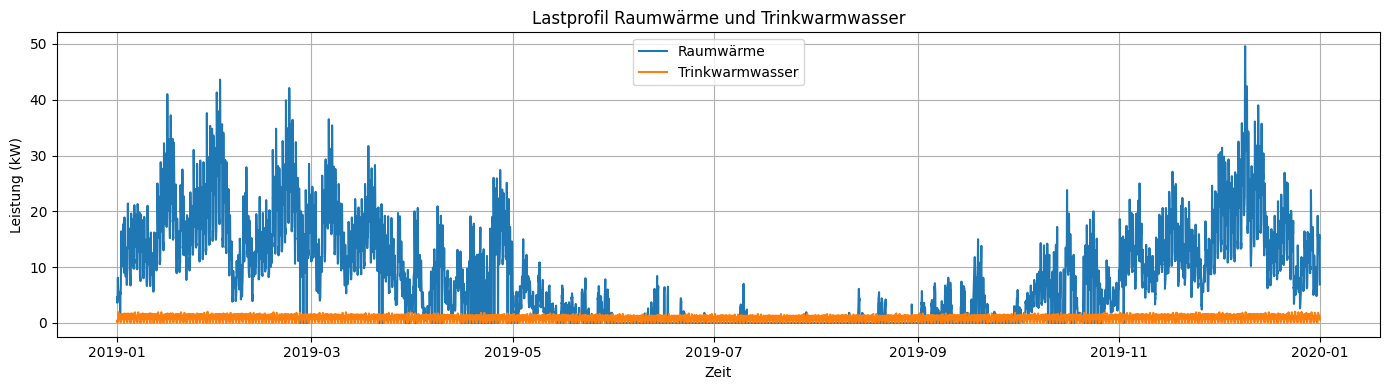

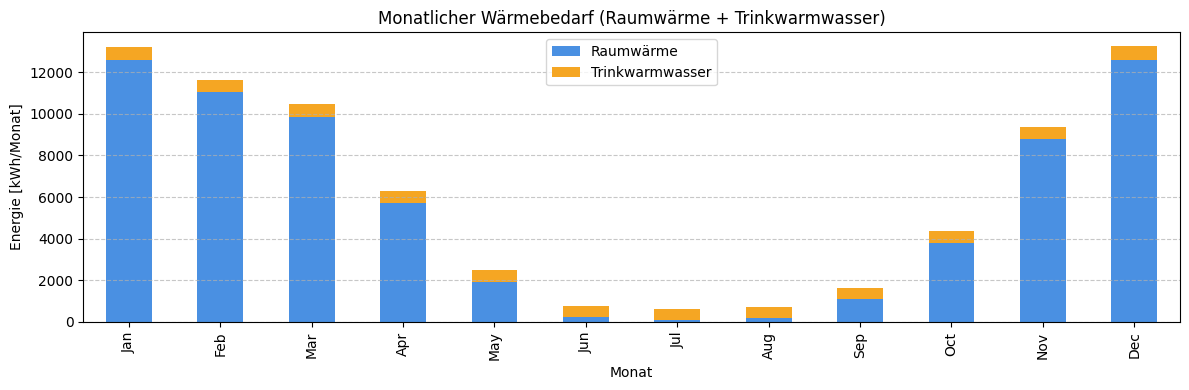

In [29]:
# ------------------------------------------------------------
# Plot der Lasten
# ------------------------------------------------------------

plt.figure(figsize=(14,4))
plt.plot(df.index, df["Raumwaerme_(kW)"], label="Raumwärme")
plt.plot(df.index, df["Trinkwarmwasser_(kW)"], label="Trinkwarmwasser")

plt.legend()
plt.title("Lastprofil Raumwärme und Trinkwarmwasser")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Monats-Balkendiagramm: Raumwärme + Trinkwarmwasser
# ------------------------------------------------------------

# Monatsenergie berechnen (kWh/Monat bei 1h-Zeitschritt)
monthly_heat = df.resample("ME")[[
    "Raumwaerme_(kW)",
    "Trinkwarmwasser_(kW)"
]].sum()

# Monatsnamen hübsch
monthly_heat.index = monthly_heat.index.strftime("%b")

# Plot
ax = monthly_heat.plot(
    kind="bar",
    stacked=True,
    figsize=(12,4),
    color=["#4A90E2", "#F5A623"]  # Blau = Raumwärme, Orange = TWW
)

ax.set_title("Monatlicher Wärmebedarf (Raumwärme + Trinkwarmwasser)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie [kWh/Monat]")
ax.legend(["Raumwärme", "Trinkwarmwasser"])
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()



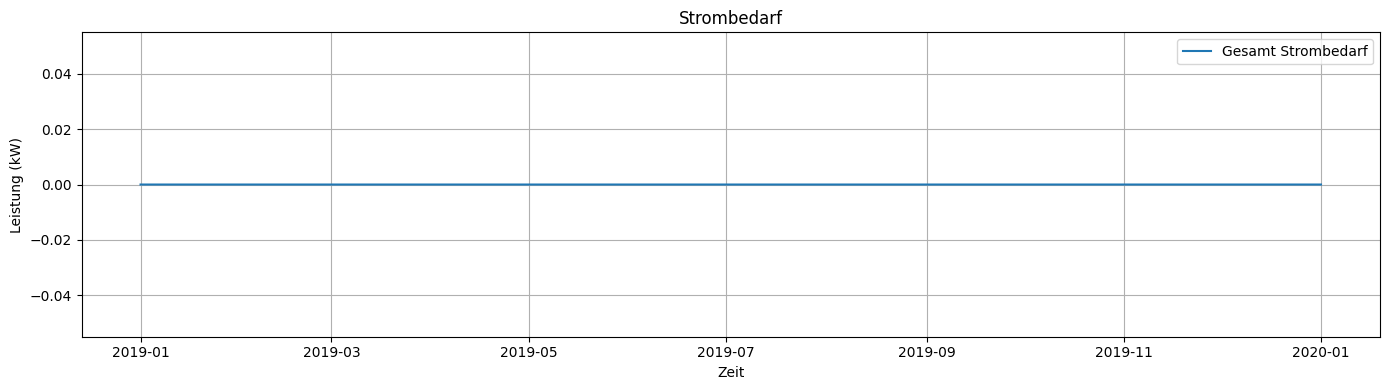

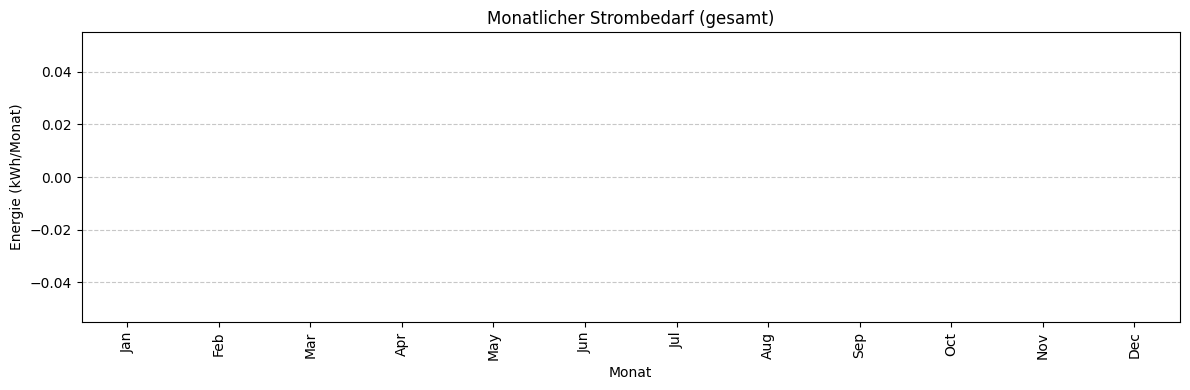

In [30]:
# ------------------------------------------------------------
# Plot der Nutzer Stromlast - momentan keine daten dazu im Lastprofil
# ------------------------------------------------------------

plt.figure(figsize=(14,4))
plt.plot(df.index, df["Strom_gesamt_(kW)"], label="Gesamt Strombedarf")

plt.legend()
plt.title("Strombedarf")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Monats-Balkendiagramm - Strom
# ------------------------------------------------------------

monthly_elec = df.resample("ME")[["Strom_gesamt_(kW)"]].sum()
monthly_elec.index = monthly_elec.index.strftime("%b")

ax = monthly_elec.plot(kind="bar", figsize=(12, 4), legend=False)
ax.set_title("Monatlicher Strombedarf (gesamt)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie (kWh/Monat)")
ax.grid(axis="y", alpha=0.7, linestyle="--")
plt.tight_layout()
plt.show()



In [31]:
# PV Erzeugungsprofil
# Annahmen: Dataset MERRA-2 (global), 2019, capacity 1kW, system loss 0.1 , Tilt 35°, Azimuth 180°, included raw data
pv = pd.read_csv(
    "../Input_Data/ninja_pv_50.9384_6.9600_corrected.csv",
    skiprows=3,
    parse_dates=["local_time"],
)

pv = pv.set_index("local_time")

pv = pv.rename(columns={
    "electricity": "pv_electricity",
    "irradiance_direct": "direct",
    "irradiance_diffuse": "diffuse",
    "temperature": "temp"
})

pv.head(100)

,time,pv_electricity,direct,diffuse,temp
local_time,,,,,
2019-01-01 01:00:00,2019-01-01 00:00,0.0,0.0,0.0,6.294
2019-01-01 02:00:00,2019-01-01 01:00,0.0,0.0,0.0,6.003
2019-01-01 03:00:00,2019-01-01 02:00,0.0,0.0,0.0,5.710
2019-01-01 04:00:00,2019-01-01 03:00,0.0,0.0,0.0,5.540
2019-01-01 05:00:00,2019-01-01 04:00,0.0,0.0,0.0,5.458
...,...,...,...,...,...
2019-01-05 00:00:00,2019-01-04 23:00,0.0,0.0,0.0,2.187
2019-01-05 01:00:00,2019-01-05 00:00,0.0,0.0,0.0,2.378
2019-01-05 02:00:00,2019-01-05 01:00,0.0,0.0,0.0,2.531


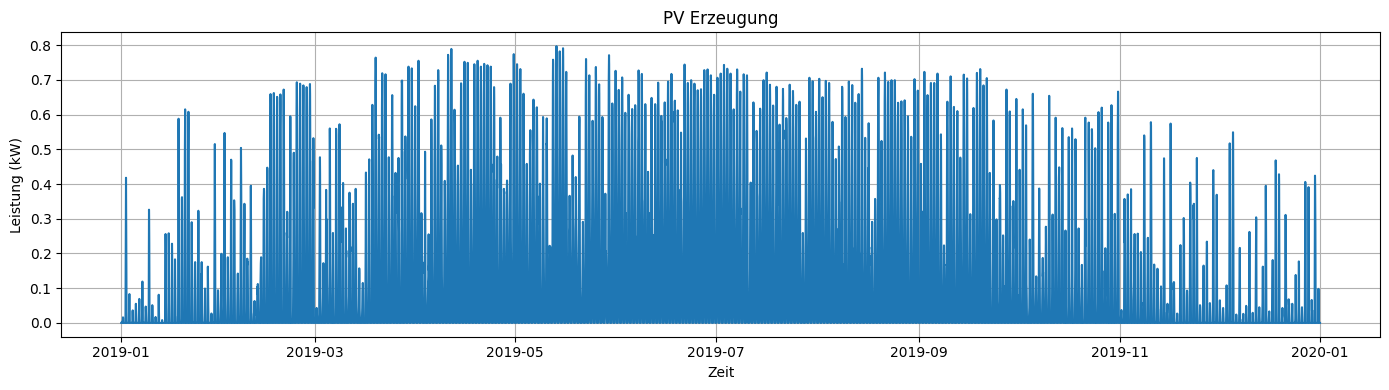

In [32]:
# Erzeugungsprofil PV plotten
plt.figure(figsize=(14,4))
plt.plot(pv.index, pv["pv_electricity"], label="PV (kW)")
plt.title("PV Erzeugung")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# ------------------------------------------------------------
# Außentemperaturdaten laden
# ------------------------------------------------------------

weather = pd.read_csv(
    "../Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv",
    skiprows=3,
    parse_dates=["local_time"]
)

# Index setzen
weather = weather.set_index("local_time")

# Umbenennen: t2m → T_outdoor
weather = weather.rename(columns={"t2m": "T_outdoor"})

# Nur Temperatur extrahieren
T_outdoor = weather["T_outdoor"]

T_outdoor.head()

local_time
2019-01-01 01:00:00    6.294
2019-01-01 02:00:00    6.003
2019-01-01 03:00:00    5.710
2019-01-01 04:00:00    5.540
2019-01-01 05:00:00    5.458
Name: T_outdoor, dtype: float64

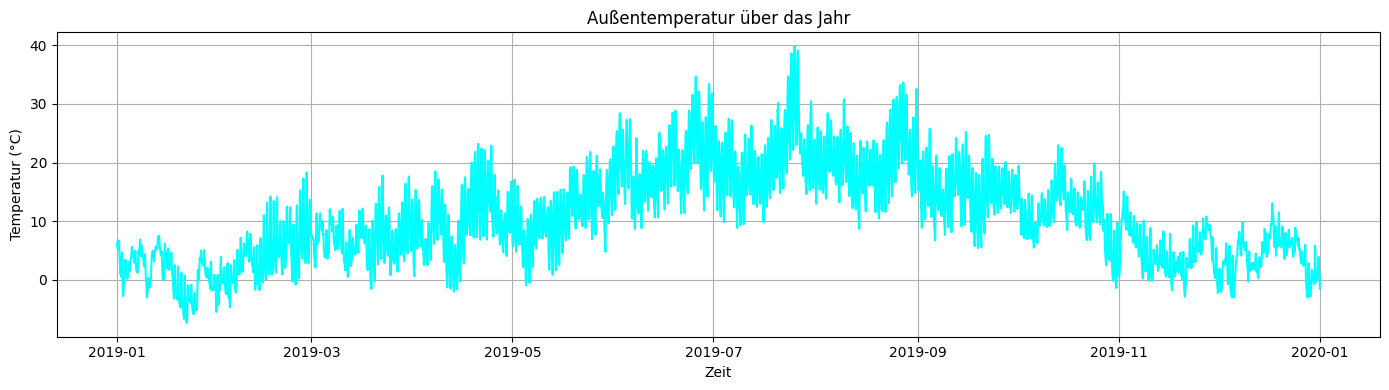

In [34]:
# -------------------------------------------
# Außentemperatur plotten
# -------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(weather.index, weather["T_outdoor"], label="Außentemperatur (°C)", color="cyan")

plt.title("Außentemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
"""
# --- Raumwärme-Lastprofile mit Cutoff speichern ---
#

cutoff = 15.0
col_heat = "Raumwaerme_(kW)"
weather_file = "./Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv"
load_files = [
    "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_Ist_ZST.csv",
    "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_konventionell.csv",
    "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_zukunftsfuehrend.csv",
]

# Wetter: "time" als Index verwenden (hat eindeutige Zeitpunkte)
w = pd.read_csv(weather_file, skiprows=3, parse_dates=["time"])
Tout = w.set_index("time")["t2m"].sort_index()   # °C

out_dir = Path("./Output")
out_dir.mkdir(parents=True, exist_ok=True)

for f in load_files:
    df = pd.read_csv(f, sep=",", decimal=".")

    # Zeitspalte Lastprofile -> datetime (2019-...)
    time_col = next((c for c in df.columns if "zeit" in c.lower()), None)
    df["time"] = pd.to_datetime("2019-" + df[time_col].astype(str),
                                format="%Y-%d-%m %H:%M", errors="coerce")

    df = df.dropna(subset=["time"]).set_index("time").sort_index()

    # Temperatur auf gleiche Zeitpunkte ziehen
    Tout_aligned = Tout.reindex(df.index)

    # Raumwärme abschalten, wenn >= 15°C
    df.loc[Tout_aligned >= cutoff, col_heat] = 0.0

    # optional fürs Debugging:
    df["T_outdoor"] = Tout_aligned

    out_path = out_dir / f"{Path(f).stem}_Raumwaerme_cutoff15C.csv"
    df.to_csv(out_path, index=True)
    print("geschrieben:", out_path)

""" 

'\n# --- Raumwärme-Lastprofile mit Cutoff speichern ---\n#\n\ncutoff = 15.0\ncol_heat = "Raumwaerme_(kW)"\nweather_file = "./Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv"\nload_files = [\n    "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_Ist_ZST.csv",\n    "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_konventionell.csv",\n    "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_zukunftsfuehrend.csv",\n]\n\n# Wetter: "time" als Index verwenden (hat eindeutige Zeitpunkte)\nw = pd.read_csv(weather_file, skiprows=3, parse_dates=["time"])\nTout = w.set_index("time")["t2m"].sort_index()   # °C\n\nout_dir = Path("./Output")\nout_dir.mkdir(parents=True, exist_ok=True)\n\nfor f in load_files:\n    df = pd.read_csv(f, sep=",", decimal=".")\n\n    # Zeitspalte Lastprofile -> datetime (2019-...)\n    time_col = next((c for c in df.columns if "zeit" in c.lower()), None)\n    df["time"] = pd.to_datetime("2019-" + df[time_col].astype(str),\n                           

In [36]:
### Auslegung der Komponenten
# Daten aus angehangen Quellen - Excel

In [37]:
# ------------------------------------------------------------
# Heizkörper vs. Fußbodenheizung über Heizkurve (flow_temperature)
# ------------------------------------------------------------

# Flag: True = Heizkörper, False = Fußbodenheizung
use_radiators = True

# HK T_vorlauf = 45 - 55 °C; FBH T_Vorlauf = 30-35 °C
T_vorlauf = 51.0 if use_radiators else 33.0         # 49 °C bei 0°C ; bzw 33 bei 0°C (nach Quelle - 30°C bei -10°C - 55° bei -10°C)
T_gradient = 6/15 if use_radiators else 3/15        # wie stark die Vorlauftemperatur mit der Außentemp. steigt/fällt

# Heizkurve berechnen (PyPSA_heat-Funktion)
T_flow = ph.physics.flow_temperature(T_vorlauf, T_gradient, T_outdoor)

heating_cutoff = 15.0                          # °C Außentemperatur, ab der nicht mehr geheizt wird
heat_on = T_outdoor <= heating_cutoff
T_flow_min = 45 if use_radiators else 30       # Mindestvorlauftemperatur
T_flow = T_flow.clip(lower=T_flow_min)
T_flow = T_flow.where(heat_on, T_flow_min)

#Rücklauftemperatur vorgeben
delta_T = 10.0 if use_radiators else 5.0       # FBH hat geringere Rücklauftemperatur ~ %°C
store_T_return  = T_flow_min - delta_T          # °C Rücklauftemperatur



# --------------------------------
# Parametrisierung der Komponenten
# --------------------------------

#Strom
grid_power      =   87        # kW Hausanschluss Leistung
grid_cost       =   0.372     # €/kWh Kosten für Netzstrombezug

interest_rate = 0.02

# PV
pv_invest       =   731     # €/kWp (einmalig)
pv_lifetime     =   20      # Jahre
PV_power        =   13      # kWp
feed_in_tariff  =   -0.0778   # €/kWh

pv_annuity = pv_invest * ((1+interest_rate)**pv_lifetime) * interest_rate / ((1+interest_rate)**pv_lifetime - 1)


#Batterie
battery_invest           = 500     #€/kWh
#Battery_marginal_cost   = 0.0     # Grenzgestehungskosten für Batterie?
battery_lifetime         = 20      # Jahre
battery_annuity = battery_invest * ((1+interest_rate)**battery_lifetime) * interest_rate / ((1+interest_rate)**battery_lifetime - 1)


#Wärmespeicher - ggf. andere werte anpassen
store_height    =   2.15      #m
store_base      =   0.708     #m²
# Volumen = store_base * store_height = 1.52 m³
# wärmekapazität wasser = 1.16
#
store_u_wall    =   0.36      #W/(m²*K)
store_T_layers  =   [60, 58, 56, 54, 52, 50, 48, 46, 44, 42, 40] if use_radiators else [60, 58, 56, 54, 52, 50, 48, 46, 44, 42, 40, 38, 36, 34, 32, 30]      #°C Temperaturschichten; !
store_invest    =   1690      # €/kWh
store_lifetime  =   20       # Jahre
store_annuity   = store_invest * ((1+interest_rate)**store_lifetime) * interest_rate / ((1+interest_rate)**store_lifetime - 1)

# Wärmepumpe
HP_power        =   30    #kW Wärmepumpenleistung
HE_power        =   9       #kW Heizstableistung



store_T_return

35.0

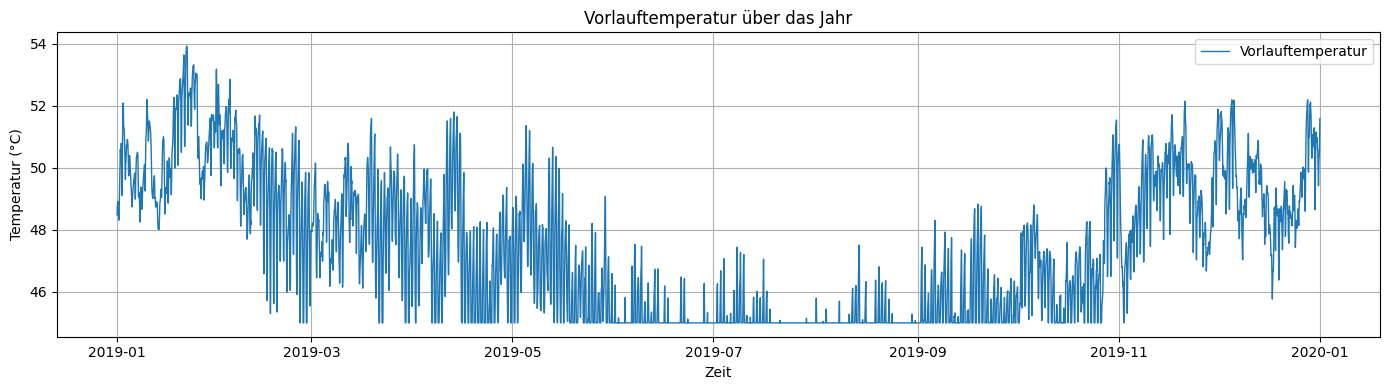

In [38]:
plt.figure(figsize=(14,4))
plt.plot(weather.index, T_flow, label="Vorlauftemperatur", linewidth=1)

plt.title("Vorlauftemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
# ---------------------------------------------
# Energiesystem
# ---------------------------------------------

# ------------------------------------------------------------
# Elektrisches System
# ------------------------------------------------------------
# # Strombus
n.add("Bus", "electricity_grid")            # Hausnetz (Last + Import)
n.add('Bus', name = 'electricity_infeed')   # PV-Seite (Erzeugung + Export)

# Netz-Generator (Strombezug aus dem Hausnetz)
n.add(
    "Generator",
    name="grid_import",
    bus="electricity_grid",
    p_nom=grid_power,
    marginal_cost=grid_cost # €/kwh  # Literaturwert nehmen!
)

# PV-Generator
n.add(
    "Generator",
    name="pv_generation",
    bus="electricity_infeed",
    p_nom=PV_power,                             # kW_peak,
    p_max_pu=pv["pv_electricity"].values,
    capital_cost=pv_annuity,                  # jährliche kosten pro einheit installierter Leistung

)

# Einspeisung (Export) von der PV-Seite
n.add(
    'Generator',
    name = 'pv_infeed',
    bus = 'electricity_infeed',
    p_nom =PV_power,                    # max Exportleistung (z.B. PV_power oder Hausanschluss)
    marginal_cost =feed_in_tariff,      #
    sign = -1)                          #  <-- macht es zur Senke (Energie Export)

# Link: PV -> Hausnetz
n.add(
    "Link",
    name="electricity_link",
    bus0="electricity_infeed",
    bus1="electricity_grid",
    p_nom=PV_power,
    efficiency=1.0
)


# ------------------------------------------------------------
# Batteriespeicher
# ------------------------------------------------------------

# Battery-Store
n.add(
    "StorageUnit",
    name = "store_el",
    bus = "electricity_grid",
    e_nom_extendable = True,
    e_cyclic = True,
    standing_loss = 0.01,                        # Verluste pro Stunde [%] (Platzhalter)
    capital_cost = battery_annuity,               # Investitionskosten €/kWh (Platzhalter)
    lifetime=20,                                 # Jahre (Platzhalter)
    build_year=2025,                             # Baujahr (Platzhalter)
    efficiency_store= 0.95,                      #
    efficiency_dispatch=0.95,
)


# ------------------------------------------------------------
# Wärmespeicher
# ------------------------------------------------------------
# Konstant geschichteter Speicher:
# - constant="temperature"
# - T_layer: feste Temperaturschichten
# - T_return: Rücklauftemperatur
# - cyclic=True: Speicherzustand am Ende = am Anfang

n.add(
    "HeatStore",
    name="hs_mfh",              # # hs = heat store (Wärmespeicher)
    constant="temperature",
    height=store_height,                # Höhe [m] (Platzhalter)
    base=store_base,                  # Grundfläche [m²] → Volumen ~ 4 m³
    T_layer=store_T_layers,  # Temperaturschichten [°C]
    T_return=store_T_return,               # Rücklauftemperatur [°C]
    V_initial=[0,0,0,0,0,0],
    cyclic=True,                            # Anfangs- und Endzustand identisch (V_initial)
    T_amb=18.0,                # Umgebungstemperatur des Speichers [°C]
    U_wall=store_u_wall                 # U-Wert der Dämmung [W/(m²*K)] (Platzhalter)
)


# ------------------------------------------------------------
# Wärmepumpe (HeatPump)
# ------------------------------------------------------------

n.add(
    "HeatPump",
    name="hp_mfh",
    bus0="electricity_grid",        # elektrische Seite am Strombus
    heat_store="hs_mfh",            # thermische Seite am Wärmespeicher
    p_nom=HP_power,                 # thermische Nennleistung in kW
    T_source=T_outdoor.values,      # Quelltemperatur = Außentemperatur (Luft-Wasser-Wärmepumpe)
    T_max = 60,
    heat_source="air"               # Luft als Quelle
)

# ------------------------------------------------------------
# Elektrischer Heizstab (HeatingElement)
# ------------------------------------------------------------

n.add(
    "HeatingElement",
    name="backup_heater",
    bus0="electricity_grid",
    heat_store="hs_mfh",
    p_nom=HE_power, # elektrische Nennleistung in kW
    efficiency=0.95
)




# ------------------------------------------------------------
# Loads des Energiesystems definieren
# ------------------------------------------------------------
p_el = df["Strom_gesamt_(kW)"].values
p_raumwaerme = df["Raumwaerme_(kW)"].values
p_warmwasser = df["Trinkwarmwasser_(kW)"].values

# Elektrische Last
n.add(
    "Load",
    name="el_demand",
    bus="electricity_grid",
    p_set=p_el
)

# Raumwärme
n.add(
    "HeatLoad",
    name="Raumwaerme",
    heat_store="hs_mfh",
    p_set=p_raumwaerme,
    T_demand=T_flow.values
)

# Warmwasser
n.add(
    "HeatLoad",
    name="dhw",
    heat_store="hs_mfh",
    p_set=p_warmwasser,
    T_demand=60.0
)




c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\pypsa\components.py:836: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_df = pd.concat([cls_df, obj_df], sort=False)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\pypsa\components.py:836: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_df = pd.concat([cls_df, obj_df], sort=False)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\pypsa\components.py:836: FutureWarning: The 

In [40]:
# ------------------------------------------------------------
# Optimierung & Plot
# ------------------------------------------------------------

n.optimize(solver_name="gurobi")


sns_to_plot = snapshots[::24]   # jeden Tag ein Punkt
ph.plot.plot_stratified_heat_store(
    n,
    hs="hs_mfh",
    sns=sns_to_plot
)


Index(['electricity_link'], dtype='object', name='Link')
Index(['electricity_grid', 'electricity_infeed'], dtype='object', name='Bus')


MemoryError: Unable to allocate 282. MiB for an array with shape (8760, 11, 768) and data type int32

In [ ]:
# ============================================================
# Energiesystem: Ergebnisse & Kennzahlen
# ============================================================

print("====================================")
print("Energiesystem – Überblick")
print("====================================")

# ------------------------------------------------------------
# 1) Komponenten-Auslegung (Nennleistungen)
# ------------------------------------------------------------

print("\n--- Komponenten ---")

# Generatoren (klassisch)
if "pv_generation" in n.generators.index:
    print("PV Leistung [kW]:", n.generators.loc["pv_generation", "p_nom"])

if "grid_import" in n.generators.index:
    print("Netzanschluss [kW]:", n.generators.loc["grid_import", "p_nom"])

# PyPSA-Heat Komponenten (generic API)
hp_df = n.df("HeatPump")
he_df = n.df("HeatingElement")
hs_df = n.df("HeatStore")

if "hp_mfh" in hp_df.index:
    # je nach Version p_nom oder p_nom_opt (wenn extendable)
    if "p_nom_opt" in hp_df.columns:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom_opt"])
    else:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom"])

if "backup_heater" in he_df.index:
    if "p_nom_opt" in he_df.columns:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom_opt"])
    else:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom"])

# Wärmespeicher-Auslegung (Geometrie / Dämmung)
if "hs_mfh" in hs_df.index:
    print("\n--- Wärmespeicher (hs_mfh) ---")
    for col in ["height", "base", "U_wall", "T_return", "T_amb"]:
        if col in hs_df.columns:
            print(f"{col}: {hs_df.loc['hs_mfh', col]}")


In [ ]:
# Batteriedaten abfragen:

print("StorageUnits vorhanden:", getattr(n, "storage_units", pd.DataFrame()).index.tolist())

if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index:
    print("\nstore_el Parameter:")
    print(n.storage_units.loc["store_el"])
    print("\nstore_el dispatch time series vorhanden?:",
          "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns)
else:
    print("store_el ist nicht im Network gelandet.")

In [ ]:
# ============================================================
# Wärmepumpe (hp_mfh): Kennzahlen, COP-Verlauf, JAZ (Layer-korrekt)
# ============================================================
# noch ausgeben lassen wie viel % der Wärme die WP abdeckt und wie viel % der Heizstab!!!

hp_name = "hp_mfh"

hp_df = n.df("HeatPump")        # Tabelle Parameter HP
hp_t  = n.pnl("HeatPump")       # Zeitreihen-Container pro Std. für HP (p_heat, p_elec, COP)

# hp_t =
#   "p_heat":  Zeitreihe(n),
#   "p_elec":  Zeitreihe(n),
#   "COP":     Zeitreihe(n),
#   ...
#   }

print("\n====================================")
print(f"Wärmepumpe – Auswertung ({hp_name})")
print("====================================")

# --- Modellergebnisse der WP  ---
cop_model  = hp_t["COP"][hp_name]         # kommt aus unserem Model und kann mehere Temperaturschichten enthalten
p_el_model = hp_t["p_elec"][hp_name]      # p_el_model = elektrische Leistung der WP
p_th_model = hp_t["p_heat"][hp_name]      # p_th_model = thermische Leistung der WP

# ============================================================
# kurzer Einschub Plot: COP je Temperaturlayer darstellen
# ============================================================

plt.figure(figsize=(14,4))

if isinstance(cop_model, pd.DataFrame):
    # Mehrere Temperaturlayer → jede Spalte wird eine Linie
    plt.plot(cop_model.index, cop_model.values, linewidth=0.6)
    plt.title("COP der Wärmepumpe je Temperaturlayer über das Jahr (Modell)")
else:
    # Nur ein Layer
    plt.plot(cop_model.index, cop_model.values, linewidth=0.8)
    plt.title("COP der Wärmepumpe über das Jahr (Modell)")

plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================
# jetzt weiter mit Code
# ============================================================


# --- Zeitindex (für Plot & Resample) ---
time_index = pd.DatetimeIndex(df.index)

# p_heat / p_elec: Gesamtleistung (Summe über Layer, falls nötig)

# Typabfrage mit isinstance(..) = ist p_th_model ein DataFrame (mehere Layer)
# wenn p_th_model ein DataFrame ist, dann summe über alle Layer, sonst nur über 1. Layer - damit # der Layer anpassbar
p_th_total = p_th_model.sum(axis=1) if isinstance(p_th_model, pd.DataFrame) else p_th_model
p_el_total = p_el_model.sum(axis=1) if isinstance(p_el_model, pd.DataFrame) else p_el_model

# optional: Modell-COP als Mittel (nur Info)
# mean(axis=1) bedutet arithmetischer Mittelwert aller Layer-COPs pro Stunde
# Das ist der gemittelte Modell-COP über alle Temperaturschichten.
# cop_model_mean ist der aus dem Modell resultierende, über alle Temperaturlayer gemittelte COP und dient ausschließlich der qualitativen Interpretation, nicht der energetischen Bewertung.
cop_model_mean = cop_model.mean(axis=1) if isinstance(cop_model, pd.DataFrame) else cop_model

# Datetime-Series
# p_el_s = die stündliche elektrische Leistung der WP
# np.asarray(p_el_s, dtype=float) erzwingt numpy-Array-Konvertierung (robuste Statistik)
# pd.series baut daraus eine Zeitreihe - jeder Wert bekommt einen Zeitstempel aus dem time_index
# „Ich nehme Daten aus der Simulation und mache daraus eine saubere, zeitlich zuordenbare Serie.“
# p_el_ts = elektrische Leistung der Wp pro std in pd.series
p_el_ts = pd.Series(np.asarray(p_el_total, dtype=float), index=time_index)
p_th_ts = pd.Series(np.asarray(p_th_total, dtype=float), index=time_index)
cop_model_ts = pd.Series(np.asarray(cop_model_mean, dtype=float), index=time_index)

# Physikalischer COP aus Q/P
# Betriebs COP der WP pro stunde
# p_th_ts = Wärmeleistung der WP (kW_th) pro Stunde
# p_el_ts = Elektrische Leistung der WP (kW_el) pro Stunde
# p_el_ts.replace(0, np.nan) = ersetzt alle Stellen, wo der Stromverbrauch 0 ist, durch NaN.
cop_phys_ts = p_th_ts / p_el_ts.replace(0, np.nan)

# --- Auslegung ---
# wenn es die Spalte p_nom gibt → Wert auslesen
# sonst → None, Schutz falls das Modell p_nom nicht gesetzt ist
P_th_nom_val = float(hp_df.loc[hp_name, "p_nom"]) if "p_nom" in hp_df.columns else None
print("\n--- Auslegung ---")
if P_th_nom_val is not None:
    print(f"Thermische Nennleistung p_nom: {P_th_nom_val:.2f} kW_th")

# --- Kennzahlen (COP phys) ---
# np.nanmean(...), np.nanmedian(...), etc. sind numpy-Funktionen
# float() wandelt Ergebnis in Python Scalar für print(..), weiterrechnen usw.
COP_mean   = float(np.nanmean(cop_phys_ts.values))      # Durchschnittlicher Betriebs-COP
COP_median = float(np.nanmedian(cop_phys_ts.values))    # Median-Betriebs-COP
COP_min    = float(np.nanmin(cop_phys_ts.values))       # Schlechtester Betriebszustand
COP_max    = float(np.nanmax(cop_phys_ts.values))       # Bester Betriebszustand

print("\n--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---")
print(f"COP Mittelwert: {COP_mean:.2f}")
print(f"COP Median:     {COP_median:.2f}")
print(f"COP Minimum:    {COP_min:.2f}")
print(f"COP Maximum:    {COP_max:.2f}")

# --- Jahresenergien ---
E_hp = float(np.nansum(p_el_ts.values))  # kWh_el/a
Q_hp = float(np.nansum(p_th_ts.values))  # kWh_th/a
# .values → NumPy-Array der Zahlen, np.nansum(...) → summiert alles, ignoriert NaNs, float(...) → macht daraus eine normale Zahl

print("\n--- Jahresenergien ---")
print(f"WP Stromverbrauch: {E_hp:.2f} kWh_el/a")
print(f"WP Wärmeerzeugung: {Q_hp:.2f} kWh_th/a")

# --- JAZ Berechnung ---
print("\n--- JAZ ---")
JAZ_hp = (Q_hp / E_hp) if E_hp > 0 else np.nan
print(f"JAZ_HP (Q_hp / E_hp): {JAZ_hp:.3f}")


# --- Ergebnis Plots:  ---

# Wärmepumpe: elektrische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_el_ts.index, p_el_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: elektrische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_el [kW_el]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: thermische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_th_ts.index, p_th_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: thermische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_th [kW_th]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: Betriebs COP über das Jahr
plt.figure(figsize=(14,4))
plt.plot(cop_phys_ts.index, cop_phys_ts.values, linewidth=0.8, label="COP phys (Q/P)")
plt.title("COP der Wärmepumpe über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Monatsmittel COP (phys) ---
cop_monthly = cop_phys_ts.resample("ME").mean()
cop_monthly.index = cop_monthly.index.strftime("%b")

plt.figure(figsize=(10,4))
plt.bar(cop_monthly.index, cop_monthly.values)
plt.title("Monatlicher mittlerer COP der Wärmepumpe (phys)")
plt.xlabel("Monat")
plt.ylabel("COP [-]")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()





In [ ]:
# ---------------------------------------
# Heizstab-Auswertung (backup_heater)
# ---------------------------------------

name = "backup_heater"

# verfügbare Keys anschauen
print("heating_elements_t keys:", list(n.heating_elements_t.keys()))

# helper: erste passende Zeitreihe nehmen
def get_ts(d, candidates):
    for c in candidates:
        if c in d:
            return d[c]
    raise KeyError(f"Keiner der Keys {candidates} in heating_elements_t vorhanden.")

# Kandidaten für "thermische Leistung" und "elektrische Leistung"
heat_key = get_ts(n.heating_elements_t, ["p_heat", "p1", "p_out", "p"])
elec_key = get_ts(n.heating_elements_t, ["p_elec", "p0", "p_in"])

# Das sind DataFrames → Spalte auswählen
p_heat = heat_key[name]
p_elec = elec_key[name]

print("\n--- Peaks ---")
print("max p_heat [kW]:", float(p_heat.max()))
print("max p_elec [kW]:", float(p_elec.max()))

# electrisch im jahr genutzt
# thermisch im jahr produziert

# Plot
plt.figure(figsize=(15,4))
plt.plot(p_heat.index, p_heat.values, linewidth=0.6)
plt.title("Heizstab: thermische Leistung über die Zeit")
plt.xlabel("Zeit")
plt.ylabel("p_heat [kW_th]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)
# ============================================================

# Heizstab: Jahreswärme
Q_he = float(np.nansum(p_heat.values))   # kWh_th/a

# WP: Jahreswärme (hast du schon)
Q_wp = float(Q_hp)                       # kWh_th/a

Q_total = Q_wp + Q_he

wp_share = (Q_wp / Q_total) * 100 if Q_total > 0 else np.nan
he_share = (Q_he / Q_total) * 100 if Q_total > 0 else np.nan

print("\n====================================")
print("Deckungsanteile Wärmeerzeugung")
print("====================================")
print(f"Wärmepumpe: {wp_share:.2f} %")
print(f"Heizstab:   {he_share:.2f} %")
print(f"Gesamtwärme: {Q_total:.0f} kWh_th/a")

In [ ]:
# ================================
#  Strombilanz - Netzbezug - PV Gen. - Einspeisung etc.
# ================================

time_index = pd.DatetimeIndex(df.index)

# --- 1) PV generation (kW) ---
pv_gen = n.generators_t.p["pv_generation"]  # kW, >=0

# --- 2) Grid import (kW) ---
grid_import = n.generators_t.p["grid_import"]  # kW, >=0

# --- 3) Feed-in / export (kW, make it positive) ---
if "pv_infeed" in n.generators_t.p.columns:
    export = -n.generators_t.p["pv_infeed"]     # kW, >=0
else:
    export = pd.Series(0.0, index=n.snapshots)

# --- 4) Household electric load (kW) ---
load_el = n.loads_t.p["el_demand"]  # kW

# --- 5) Heat pump electric consumption (kW) ---
hp_t = n.pnl("HeatPump")
hp_p_el = hp_t["p_elec"]["hp_mfh"]
hp_p_el_total = hp_p_el.sum(axis=1) if isinstance(hp_p_el, pd.DataFrame) else hp_p_el  # kW

# --- 6) Heating element electric consumption (kW) ---
he_t = n.pnl("HeatingElement")
he_p_el = he_t["p_elec"]["backup_heater"]
he_p_el_total = he_p_el.sum(axis=1) if isinstance(he_p_el, pd.DataFrame) else he_p_el  # kW

# --- 7) Battery (kW): StorageUnit p > 0 discharges to bus, p < 0 charges from bus ---
if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index and \
   "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns:
    bat_p = n.storage_units_t.p["store_el"]  # kW
    bat_charge = (-bat_p).clip(lower=0)      # kW charging
    bat_discharge = (bat_p).clip(lower=0)    # kW discharging
else:
    bat_charge = pd.Series(0.0, index=n.snapshots)
    bat_discharge = pd.Series(0.0, index=n.snapshots)

# --- Total electric consumption on the grid bus (kW) ---
# This is what must be covered by PV (via link), battery discharge, and grid import.
total_consumption = load_el + hp_p_el_total + he_p_el_total + bat_charge

# --- Energies (kWh) for hourly data: sum of kW values ---
E_grid = float(grid_import.sum())
E_cons = float(total_consumption.sum())
E_pv = float(pv_gen.sum())
E_exp = float(export.sum())
E_bat_chg = float(bat_charge.sum())
E_bat_dis = float(bat_discharge.sum())

autarkiegrad = 1 - (E_grid / E_cons) if E_cons > 0 else np.nan

print("\n--- Strombilanz ---")
print(f"Verbrauch gesamt (HH+WP+HE+BattLaden): {E_cons:.0f} kWh/a")
print(f"Netzbezug:                             {E_grid:.0f} kWh/a")
print(f"PV-Erzeugung:                          {E_pv:.0f} kWh/a")
print(f"Einspeisung (Export):                  {E_exp:.0f} kWh/a")
print(f"Batterie Laden:                        {E_bat_chg:.0f} kWh/a")
print(f"Batterie Entladen:                     {E_bat_dis:.0f} kWh/a")
print(f"Autarkiegrad:                          {autarkiegrad*100:.1f} %")

# --- Plot: power time series ---
plt.figure(figsize=(14,4))
plt.plot(time_index, grid_import.values, label="Grid import [kW]", linewidth=0.8)
plt.plot(time_index, pv_gen.values, label="PV generation [kW]", linewidth=0.8)
plt.plot(time_index, total_consumption.values, label="Total consumption [kW]", linewidth=0.8)
plt.plot(time_index, export.values, label="Export [kW]", linewidth=0.8)
plt.title("Electricity: PV, consumption, grid import, export")
plt.xlabel("Time")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Monthly energy bars (kWh/month) ---
pv_ts   = pd.Series(pv_gen.to_numpy(), index=time_index)
cons_ts = pd.Series(total_consumption.to_numpy(), index=time_index)
imp_ts  = pd.Series(grid_import.to_numpy(), index=time_index)
exp_ts  = pd.Series(export.to_numpy(), index=time_index)
chg_ts  = pd.Series(bat_charge.to_numpy(), index=time_index)
dis_ts  = pd.Series(bat_discharge.to_numpy(), index=time_index)

monthly = pd.DataFrame({
    "PV generation":     pv_ts.resample("ME").sum(),
    "Total consumption": cons_ts.resample("ME").sum(),
    "Grid import":       imp_ts.resample("ME").sum(),
    "Export":            exp_ts.resample("ME").sum(),
    "Battery charge":    chg_ts.resample("ME").sum(),
    "Battery discharge": dis_ts.resample("ME").sum(),
})
monthly.index = monthly.index.strftime("%b")

ax = monthly.plot(kind="bar", figsize=(13,4))
ax.set_title("Monthly electricity balance (kWh/month)")
ax.set_xlabel("Month")
ax.set_ylabel("Energy [kWh/month]")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print("Objective (total system cost):", n.objective)
print("Capital expenditures (CAPEX):", n.statistics.capex())
print("Operational expenditures (OPEX):", n.statistics.opex())
grid_costs_total = grid_cost * E_grid
print("Gridcosts", grid_cost * E_grid)
costs_total = n.objective + grid_costs_total
print("Total costs", costs_total)

In [ ]:
warmegesthehungskosten = costs_total / Q_hp     # Heizstab noch hinzu
print(f"Wärmegestehungskosten: {warmegesthehungskosten:.2f} €/kWh_th")


In [ ]:
# ============================================================
# Ergebnis-CSV
# ============================================================

scenario_id = f"{lastgang_version}__Tv{int(T_vorlauf)}__{'HK' if use_radiators else 'FBH'}"
# z.B. "ist_zst__Tv55__HK"

results_row = {
    "scenario_id": scenario_id,
    "lastgang_version": lastgang_version,
    "lastgang_file": lastgang_file,
    "use_radiators": use_radiators,
    "T_vorlauf_C": float(T_vorlauf),
    "JAZ_wp": float(JAZ_hp),
    "waermegestehungskosten_EUR_per_kWh_th": float(warmegesthehungskosten),
    "Total_costs_€/a": float(n.objective),
    "CAPEX_€/a": float(n.statistics.capex()),
    "OPEX_€/a": float(n.statistics.opex()),
    "grid_import_kWh": float(E_grid),
    "Q_hp_kWh_th": float(Q_hp),
    "E_hp_kWh_el": float(E_hp),
}

BASE_DIR = Path.cwd()

results_dir = BASE_DIR / "Output" / "sensitivity_runs"
results_dir.mkdir(parents=True, exist_ok=True)

results_path = results_dir / f"results_{scenario_id}.csv"

df_out = pd.DataFrame([results_row])
df_out.to_csv(results_path, index=False)

print(f"\n Neue Datei pro Run gespeichert in:\n{results_path.resolve()}")


In [ ]:
# ============================================================
# Temperatur-Zeitreihen exportieren

# ------------------------------------------------------------
# 1) Labels für Dateinamen
# ------------------------------------------------------------
system_label = "heizkoerper" if use_radiators else "fussbodenheizung"

# nimm was bei euch sinnvoll ist: version + dateiname (ohne .csv)
lastgang_label = f"{lastgang_version}_{Path('../Input_Data/').stem}"

# "sauberer" Dateiname (keine Leerzeichen/komische Zeichen)
def sanitize(s: str) -> str:
    return "".join(c if (c.isalnum() or c in "-_") else "_" for c in str(s))

run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
fname = f"temperaturen_{system_label}_{sanitize(lastgang_label)}_{run_id}.csv"

out_dir = Path("../Output")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / fname

# ------------------------------------------------------------
# 2) Sicherstellen, dass alle Reihen eine gemeinsame Zeitachse haben
# ------------------------------------------------------------
idx = T_outdoor.index

# falls T_flow ein numpy-array ist: wieder in Series mit Index umwandeln
if not isinstance(T_flow, pd.Series):
    T_flow = pd.Series(T_flow, index=idx, name="T_flow")

# Gleiches für T_flow_min / store_T_return, falls scalar -> als konstante Spalte
# (falls sie schon Series sind, wird automatisch aligned)
def as_series(x, name):
    if isinstance(x, pd.Series):
        return x.reindex(idx)
    return pd.Series(np.full(len(idx), float(x)), index=idx, name=name)

store_T_return_s = as_series(store_T_return, "Store_T_return")

# ------------------------------------------------------------
# 3) DataFrame bauen und exportieren
# ------------------------------------------------------------
df_temp = pd.DataFrame({
    "T_outdoor": T_outdoor.reindex(idx),
    "T_flow": T_flow.reindex(idx),
    "Store_T_return": store_T_return_s,
})

df_temp.to_csv(out_path, index=True)  # Index = Zeitstempel

print(f"Temperatur-Zeitreihen gespeichert: {out_path}")
